In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Общий анализ

In [39]:
month2num = {
    'JAN': 0,
    'FEB': 1,
    'MAR': 2,
    'APR': 3,
    'MAY': 4,
    'JUN': 5,
    'JUL': 6,
    'AUG': 7,
    'SEP': 8,
    'OCT': 9,
    'NOV': 10,
    'DEC': 11
}

def transform_date(date):
    _, month, year = date.split('-')
    return int(year) * 12 + month2num[month]



Проблема датасета:

Есть id объекта страхования, но нет id контракта. К одному объекту модет быть привязано несколько контрактов (ОСАГО, КАСКО).

Более менее идентифицировать все контракты можно по полям:

'OBJECT_ID', 'START_MNTH', 'INSURED_VALUE', 'SEX', 'PREMIUM', 'INSR_TYPE'

In [ ]:
df = pd.read_csv('~/MLOps/vehicle-insurance-data/motor_data11-14lats.csv')

df['START_MNTH'] = df['INSR_BEGIN'].apply(transform_date)
df['END_MNTH'] = df['INSR_END'].apply(transform_date)
df['DURATION'] = df['END_MNTH'] - df['START_MNTH']


df = df.sort_values(['OBJECT_ID', 'START_MNTH', 'PREMIUM', 'DURATION'])

df = df[df['DURATION'] > 0]

df = df.drop_duplicates(subset=['OBJECT_ID', 'START_MNTH', 'INSURED_VALUE', 'SEX', 'PREMIUM', 'INSR_TYPE'], ignore_index=True, keep='last')

df = df.drop(['INSR_BEGIN', 'INSR_END', 'END_MNTH', 'START_MNTH', 'EFFECTIVE_YR', 'CLAIM_PAID', 'CARRYING_CAPACITY'], axis=1).reset_index(drop=True)

print(df.shape)

df.head()


149968
(289528, 12)


,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,DURATION
0,1,1202,380000.0,34405.72,5000017899,2008.0,2.0,Truck,4334.0,ISUZU,General Cartage,12
1,1,1202,380000.0,41494.85,5000017899,2008.0,2.0,Truck,4334.0,ISUZU,General Cartage,12
2,0,1202,270000.0,6711.65,5000017900,2000.0,11.0,Bus,1998.0,TOYOTA,Own service,12
3,0,1202,270000.0,8077.01,5000017900,2000.0,11.0,Bus,1998.0,TOYOTA,Own service,12
4,0,1202,270000.0,7486.96,5000017900,2000.0,11.0,Bus,1998.0,TOYOTA,Own service,12


In [4]:
df.isna().sum()

SEX                0
INSR_TYPE          0
INSURED_VALUE      0
PREMIUM            8
OBJECT_ID          0
PROD_YEAR        106
SEATS_NUM        139
TYPE_VEHICLE       0
CCM_TON            2
MAKE               0
USAGE              0
DURATION           0
dtype: int64

# Слишком много пропусков --- удаляем

In [ ]:
# df = df.drop(['CLAIM_PAID', 'CARRYING_CAPACITY'], axis=1)

: 

In [5]:
np.unique(df['TYPE_VEHICLE'].to_numpy(), return_counts=True)

(array(['Automobile', 'Bus', 'Motor-cycle', 'Pick-up',
        'Special construction', 'Station Wagones', 'Tanker', 'Tractor',
        'Trade plates', 'Trailers and semitrailers', 'Truck'], dtype=object),
 array([52798, 40065, 37146, 54251,  3804, 24606,  4150,  3836,     7,
        14280, 54585]))

# Ошибки в марках

Можно исправлять, но сами по семе марки несут 

In [ ]:
make_map = {
    # ============ VOLKSWAGEN ============
    'V.W': 'VOLKSWAGEN',
    'VOLKSWAGON': 'VOLKSWAGEN',
    'VW': 'VOLKSWAGEN',
    'PASSAT': 'VOLKSWAGEN',
    'GOLF': 'VOLKSWAGEN',
    'VOLSWAGEN': 'VOLKSWAGEN',
    'VOWSWAGEN': 'VOLKSWAGEN',
    'VOLSVAGON': 'VOLKSWAGEN',
    
    # ============ MERCEDES ============
    'MERCEEDES': 'MERCEDES',
    'MERCEEDICE': 'MERCEDES',
    'MERCHEDES': 'MERCEDES',
    'MERCEDICE': 'MERCEDES',
    
    # ============ TOYOTA ============
    'T0Y0TA': 'TOYOTA',
    'TOYOTA*': 'TOYOTA',
    'VITZ': 'TOYOTA',
    'COROLLA': 'TOYOTA',
    'LANDCRUISER': 'TOYOTA',
    'TOYOTAL/CRUISER': 'TOYOTA',
    'ROZA': 'TOYOTA',
    'YARIS': 'TOYOTA',
    'TOYOTAPICK-UP': 'TOYOTA',
    'TOYOTALANDCRUISER': 'TOYOTA',
    
    # ============ NISSAN ============
    'NISSANUD': 'NISSAN',
    'NISSAN*': 'NISSAN',
    'UD': 'NISSAN',
    'DATSUN': 'NISSAN',
    
    # ============ MITSUBISHI ============
    'MITSUBISHI*': 'MITSUBISHI',
    'VERYCA': 'MITSUBISHI',
    'VERCYA': 'MITSUBISHI',
    
    # ============ ISUZU ============
    'ISUSU': 'ISUZU',
    'ISUZUFVR': 'ISUZU',
    
    # ============ DAEWOO ============
    'DAWOO': 'DAEWOO',
    'LANOS': 'DAEWOO',
    'MATIZ': 'DAEWOO',
    'TICO': 'DAEWOO',
    'DAMAS': 'DAEWOO',
    'LABO': 'DAEWOO',
    
    # ============ KIA ============
    'KORYA': 'KIA',
    'KORIA': 'KIA',
    'RIOLS': 'KIA',
    'RIORS': 'KIA',
    'SPORTAGE': 'KIA',
    'CARENZI': 'KIA',
    'CERATO': 'KIA',
    'PREGIO': 'KIA',
    'SORENTO': 'KIA',
    
    # ============ HYUNDAI ============
    'HYUNDIGETZ': 'HYUNDAI',
    'COBUS': 'HYUNDAI',
    'GETZ': 'HYUNDAI',
    
    # ============ SSANGYONG ============
    'MUSSO': 'SSANGYONG',
    'REXTON': 'SSANGYONG',
    'KYRON': 'SSANGYONG',
    'RODEO': 'SSANGYONG',
    'ACTYON': 'SSANGYONG',
    'KORANDO': 'SSANGYONG',
    
    # ============ LAND ROVER ============
    'LANDROVER': 'LAND ROVER',
    'DISCOVERY2.5': 'LAND ROVER',
    
    # ============ RANGE ROVER ============
    'RANGEROVER': 'RANGE ROVER',
    'RENGEROVER': 'RANGE ROVER',
    
    # ============ VOLVO ============
    'VOLVO': 'VOLVO',
    
    # ============ SUZUKI ============
    'SUZUK': 'SUZUKI',
    'SUZIKE': 'SUZUKI',
    'SUZUKIGRANDVITARA': 'SUZUKI',
    
    # ============ DAIHATSU ============
    'DAIHATSU TERIOS': 'DAIHATSU',
    'DIAHATSU': 'DAIHATSU',
    'DAHATSUN': 'DAIHATSU',
    'DIHATSU': 'DAIHATSU',
    'DIATSU': 'DAIHATSU',
    'DHATSU': 'DAIHATSU',
    'TERIOS': 'DAIHATSU',
    'DAIHATSUTERIOS': 'DAIHATSU',
    
    # ============ RENAULT ============
    'RENAULT*': 'RENAULT',
    'RENALT': 'RENAULT',
    'RENAULT/STOLARCZYK': 'RENAULT',
    
    # ============ PEUGEOT ============
    'PEAGOUT': 'PEUGEOT',
    'PAGOT': 'PEUGEOT',
    
    # ============ BAJAJ ============
    'BAJAJI': 'BAJAJ',
    
    # ============ IVECO ============
    'IVECO/CHINA': 'IVECO',
    'FRANKUNIVECO': 'IVECO',
    'GENLYONIVECO': 'IVECO',
    'IVECO/ASTRA': 'IVECO',
    
    # ============ MAHINDRA ============
    'MAHANDRA': 'MAHINDRA',
    
    # ============ FOTON ============
    'FOTTON': 'FOTON',
    'FORLAND': 'FOTON',
    
    # ============ HOWO / SINOTRUK ============
    'SINOHOWO': 'HOWO',
    'HOWO': 'SINOTRUK',
    'SINO': 'SINO TRUCK',
    'SINOTRUCK': 'SINO TRUCK',
    
    # ============ DONGFENG ============
    'DONGFENG': 'DONGFENG',
    'DUNGFING': 'DONGFENG',
    'DUNGFINF': 'DONGFENG',
    'DONFING': 'DONGFENG',
    'DANGIFAN': 'DONGFENG',
    'AEOLUS': 'DONGFENG',
    
    # ============ GEELY ============
    'GLEEY': 'GEELY',
    'ADDISGEELY': 'GEELY',
    'ADDISGELLY': 'GEELY',
    'GELION': 'GEELY',
    
    # ============ ZOTYE ============
    'ZOYTE': 'ZOTYE',
    'ZOTYE,NOMADII': 'ZOTYE',
    
    # ============ CHERRY ============
    'CHARRY': 'CHERRY',
    
    # ============ GREAT WALL ============
    'HOVER': 'GREAT WALL',
    'HAVAL': 'GREAT WALL',
    'GREATWALL': 'GREAT WALL',
    
    # ============ JAC ============
    'JAK': 'JAC',
    'JAC DUMP': 'JAC',
    'JACDUMP': 'JAC',
    
    # ============ AUDI ============
    'AUDIO': 'AUDI',
    'AU': 'AUDI',
    
    # ============ MAZDA ============
    'MAZ': 'MAZDA',
    
    # ============ FORD ============
    'FPRD': 'FORD',
    
    # ============ LADA ============
    'NIVA': 'LADA',
    
    # ============ OPEL ============
    'ASTRA': 'OPEL',
    
    # ============ DACIA ============
    'LOGAN': 'DACIA',
    
    # ============ CATERPILLAR ============
    'CATERPILLARTRACTOR': 'CATERPILLAR',
    'CAT': 'CATERPILLAR',
    'CATDOZER': 'CATERPILLAR',
    'DOZER': 'CATERPILLAR',
    'GRADER': 'CATERPILLAR',
    'LOADER': 'CATERPILLAR',
    'WHEELLOADER': 'CATERPILLAR',
    'WHEELLLOADER': 'CATERPILLAR',
    'EXCAVATOR': 'CATERPILLAR',
    'VIBRATIONROLLER': 'CATERPILLAR',
    'BACKLOADER': 'CATERPILLAR',
    
    # ============ KOMATSU ============
    'COMATSU GRADER': 'KOMATSU',
    'KOMATSU': 'KOMATSU',
    'COMATSUGRADER': 'KOMATSU',
    
    # ============ KATO ============
    'KATO': 'KATO',
    'KATOEXCAVATOR': 'KATO',
    'KATOCRAN': 'KATO',
    'KATOCRANE': 'KATO',
    'KATOCRAIN': 'KATO',
    
    # ============ JOHN DEERE ============
    'JOHNDEER': 'JOHN DEERE',
    'OHNDEERE': 'JOHN DEERE',
    'JOHNDEERE': 'JOHN DEERE',
    
    # ============ MASSEY FERGUSON ============
    'MASSYFUREGUSON': 'MASSEY FERGUSON',
    'MASILFERGUSAN': 'MASSEY FERGUSON',
    'MASSEYFERGUSON': 'MASSEY FERGUSON',
    
    # ============ BELARUS ============
    'BELARUSTRACTOR': 'BELARUS',
    'TRACTORBELARUS': 'BELARUS',
    'BELTRACTOR': 'BELARUS',
    
    # ============ KAMAZ ============
    'KAMZ': 'KAMAZ',
    'CAMZ': 'KAMAZ',
    
    # ============ TRUCK BRANDS ============
    'SHACMAN': 'SHACMAN',
    'FAW': 'FAW',
    'JIEFANG': 'FAW',
    'JMC': 'JMC',
    'DAYUN': 'DAYUN',
    'HINO': 'HINO',
    'SCANIA': 'SCANIA',
    'DAF': 'DAF',
    'TATA': 'TATA',
    'MAN': 'MAN',
    'MACK': 'MACK',
    'GEEP': 'JEEP',
    
    # ============ BUS BRANDS ============
    'HIGERBUS': 'HIGER',
    'HIGER': 'HIGER',
    'HIGHER': 'HIGER',
    'KINGLONG': 'KING LONG',
    'SUNLONGBUS': 'SUNLONG',
    'SUNLONG': 'SUNLONG',
    'JINBEI': 'JINBEI',
    
    # ============ TRAILER ============
    'TRAILER': 'TRAILER',
    'HIGHBEDTRAILER': 'TRAILER',
    'LOWBED': 'TRAILER',
    '330-30TRAILER': 'TRAILER',
    '330-30TRA': 'TRAILER',
    '330-30TR': 'TRAILER',
    'S.T.TRAILER': 'TRAILER',
    'S.TTRA': 'TRAILER',
    'S.TTR': 'TRAILER',
    'S.TTRA.': 'TRAILER',
    'S.T': 'TRAILER',
    'CHINASPECIALSEMITRAILER': 'TRAILER',
    'LONGBASETRAILER': 'TRAILER',
    'TRACTORTRAILER': 'TRAILER',
    'SUGERCANETRAILER': 'TRAILER',
    'EU.TRAILER': 'TRAILER',
    'PLATEFORM': 'TRAILER',
    'BAYBENTRUCKHIGHBED': 'BEBEN',
    
    # ============ TRAILER BRANDS ============
    'BEBEN': 'BEBEN',
    'BEBENSEMITRAILER': 'BEBEN',
    'SCHMITZ': 'SCHMITZ',
    'DORSEY': 'DORSEY',
    'RANDON': 'RANDON',
    
    # ============ MOTORCYCLE BRANDS ============
    'MOTORCYCLE': 'MOTORCYCLE',
    'MOTORCYCLE(TWOCYCLE)': 'MOTORCYCLE',
    'M/CYICLE': 'MOTORCYCLE',
    'YAMHA': 'YAMAHA',
    'TVS125': 'TVS',
    'YVS': 'TVS',
    'HERO': 'HERO',
    'LIFAN': 'LIFAN',
    'ZONGSHEN': 'ZONGSHEN',
    'ZONGUSHEN': 'ZONGSHEN',
    'ZUNGSHUN': 'ZONGSHEN',
    
    # ============ CHINESE BRANDS ============
    'BYD': 'BYD',
    'CHANA': 'CHANGAN',
    'CHANGHE': 'CHANGAN',
    'SHANTUI': 'SHANTUI',
    'SHANTUEXCAVATOR': 'SHANTUI',
    'SHANTU': 'SHANTUI',
    'CHENGLONGMOTOROFCHINA': 'CHENGLONG',
    'YOUNGMA': 'YOUNGMAN',
    'YOUTONG': 'YUTONG',
    'YUTONG': 'YUTONG',
    'YOUNGMAN': 'YOUNGMAN',
    'LONGJIANG': 'LONGJIANG',
    'ROEWE': 'ROEWE',
    
    # ============ AGRICULTURAL BRANDS ============
    'LANDINI': 'LANDINI',
    'DEUTZFAHR': 'DEUTZ-FAHR',
    'NEWHOLLAND': 'NEW HOLLAND',
    'NEWHOLAND': 'NEW HOLLAND',
    'CLASS': 'CLAAS',
    'CLASSCOMBINE': 'CLAAS',
    'VERSATILE': 'VERSATILE',
    'CASE': 'CASE',
    'YALE': 'YALE',
    'HYSTER': 'HYSTER',
    'MANITOU': 'MANITOU',
    'MANITUD': 'MANITOU',
    
    # ============ SPECIAL VEHICLES ============
    'AMBULANCE': 'AMBULANCE',
    'WATERPUMP': 'SPECIAL VEHICLE',
    'WATERINGCAR': 'SPECIAL VEHICLE',
    'DUMPINGCAR': 'DUMP TRUCK',
    'DUMPERCAR': 'DUMP TRUCK',
    'MIXER': 'CONCRETE MIXER',
    'CONCRETEMIXER': 'CONCRETE MIXER',
    'TANKER': 'TANKER',
    'REFREGERATOR': 'REFRIGERATED TRUCK',
    'REFREGIRATOR': 'REFRIGERATED TRUCK',
    'TRACTOR': 'TRACTOR',
    'TRACTOR4WD': 'TRACTOR',
    'POWERPLUSDOSER': 'SPECIAL VEHICLE',
    'POWERPLUSDOZER': 'SPECIAL VEHICLE',
    'CRANE': 'CRANE',
    'CRAIN': 'CRANE',
    'CRAIN/TRUCK': 'CRANE',
    'MOBILECRANE': 'CRANE',
    'CRANE60TON': 'CRANE',
    'ZOOMLIONCRANE': 'CRANE',
    'FORKLIFT': 'SPECIAL VEHICLE',
    'SPECIALVEHICLE': 'SPECIAL VEHICLE',
    'DUMPTRUCK': 'DUMP TRUCK',
    'REFRIGERATEDTRUCK': 'REFRIGERATED TRUCK',
    'ARTICULATEDDUMPTRUCK': 'DUMP TRUCK',
    'ARTICULATEDTRACTOR': 'TRACTOR',
    'ENGLANDTRACTOR': 'TRACTOR',
    'TRATTORE': 'TRACTOR',
    'BEBIENTANKER': 'BEBEN',
    'COREDRILLINGRING': 'SPECIAL VEHICLE',
    'RAPIDINTERVENSION': 'SPECIAL VEHICLE',
    'SPECIALTRUCKFORTOW&MAINTENANCE': 'SPECIAL VEHICLE',
    'SPECIALBUSFORTOW&MAINTENANCE': 'SPECIAL VEHICLE',
    'CHINASPECIALPOWERTRUCK': 'SPECIAL VEHICLE',
    'AIRCARGOMOBILETRUCK': 'SPECIAL VEHICLE',
    
    # ============ OTHER BRANDS ============
    'CALABRASE': 'CALABRESE',
    'CALBRESE': 'CALABRESE',
    'VIBERTI': 'VIBERTI',
    'BARTOLETI': 'BARTOLETI',
    'CACCIAMALLI': 'CACCIAMALLI',
    'CACCAMALI': 'CACCIAMALLI',
    'ROLFO': 'ROLFO',
    'ORAL': 'ORAL',
    'MARU': 'MARU',
    'MESFIN': 'MESFIN',
    'ABAY': 'ABAY',
    'BISHOFTU': 'BISHOFTU',
    'BISHEFTU': 'BISHOFTU',
    'AWASH': 'AWASH',
    'TEKEZE': 'TEKEZE',
    'NATFA': 'NATFA',
    'ZMAY': 'ZMAY',
    'ZAMAJ': 'ZAMAJ',
    'ZEPPLIN': 'ZEPPLIN',
    'PLATINA': 'PLATENA',
    'LISBO': 'LISBO',
    'SAMI': 'SAMI',
    'WINEGEL': 'WINEGEL',
    'GORICA': 'GORICA',
    'TRAKKER': 'TRAKKER',
    'TRAKER': 'TRAKKER',
    'TRAKKER380': 'TRAKKER',
    'STEYER': 'STEYR',
    'STAYER': 'STEYR',
    'SRAYER': 'STEYR',
    'GMC': 'GMC',
    'GMS': 'GMC',
    'CHEVROLET': 'CHEVROLET',
    'BMW': 'BMW',
    'FIAT': 'FIAT',
    'FIAT-OM': 'FIAT',
    'CITROEN': 'CITROEN',
    'SKODA': 'SKODA',
    'SAAB': 'SAAB',
    'ALFAROMEO': 'ALFA ROMEO',
    'ALFAROMIO': 'ALFA ROMEO',
    'ALFA': 'ALFA ROMEO',
    'LEXUS': 'LEXUS',
    'CADILLAC': 'CADILLAC',
    'JEEP': 'JEEP',
    'BELLTRACTOR': 'BELL',
    'INTERNATIONALUSE': 'INTERNATIONAL',
    
    # ============ UNKNOWN ============
    'RUSSIA': 'LADA',
    'RUSIA': 'LADA',
    'EUROTRUCKER': 'EUROTRUCKER',
    'WAZ': 'LADA',
    'LANCHA': 'FIAT',
    'HOBGYANSTYER': 'STEYR',
    'FORSCHE': 'PORSCHE',
    'UAI': 'LADA',
    'BOXER': 'PORSCHE',
    'ZOYTE,NOMADII': 'ZOTYE',
    'ZIL': 'LADA',
    'ILSBO': 'LISBO',
    'HONDA': 'HONDA',
    'FARID': 'FARID',
    'OTOYOL': 'OTOYOL',
    'MTE': 'MTE',
    'ME': 'MTE',
    'ATOZ': 'ATOZ',
    'BRIDGE': 'BRIDGE',
    'ARMORDE': 'ARMORDE',
    'HONGYAN': 'HONGYAN',
    'AFRO': 'AFRO',
    'LANJIAN': 'LANJIAN',
    'PONTIAC': 'PONTIAC',
    'MERCURY': 'CHEVROLET',
    'LIBER': 'LIBERDOZER',
    'HUMMER': 'HUMMER',
    'FORCE': 'FORCE',
    'ADGE': 'ADGE',
    'ZTLTRUCK': 'ZTL',
    'TURBOBUS': 'TURBO',
    '1982': '1982',
    'REDFOX': 'REDFOX',
    'ZZ': 'ZZ',
    'ROLLER': 'ROLLER'
}

make_map = make_map | {v: v for v in make_map.values()}

# import json
# with open('make_map.json', 'w') as f:
#     json.dump(make_map, f)

In [7]:
df['MAKE'] = df['MAKE'].apply(lambda x: x.upper().replace(' ', ''))
df['OLD_MAKE'] = df['MAKE']
df['MAKE'] = df['MAKE'].apply(lambda x: make_map.get(x, 'UNKNOWN'))

In [8]:
a = np.unique(df['OLD_MAKE'][df['MAKE'] == 'UNKNOWN'].sort_values().to_numpy(), return_counts=True)
pd.DataFrame({1: a[0], 2:a[1]}).iloc[60:70]

,1,2
60,RAMP,15
61,RIG,28
62,ROLD,7
63,S/W,12
64,SHNAY,2
65,SINALIKE,22
66,SKYBUS,29
67,SOCOOL,10
68,SONALIKA,14
69,SPAIN,13


In [9]:
a = np.unique(df['MAKE'].to_numpy(), return_counts=True)
a = pd.DataFrame({1: a[0], 2:a[1]})

a[a[2] < 20]

,1,2
4,ALFA ROMEO,16
6,ARMORDE,4
22,CASE,4
25,CHENGLONG,1
30,CONCRETE MIXER,6
37,DEUTZ-FAHR,8
39,DORSEY,5
41,EUROTRUCKER,1
52,HERO,5
56,HONGYAN,18


# Уберём пропуски в Trade plates

In [10]:
df[df['TYPE_VEHICLE'] == 'Trade plates']

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,DURATION,OLD_MAKE
203798,1,1204,50000.0,2243.0,5000304696,2000.0,0.0,Trade plates,0.0,ZZ,Others,12,ZZ
205759,0,1204,50000.0,576.9,5000310842,2012.0,0.0,Trade plates,0.0,UNKNOWN,Others,12,UNKNOWN
205760,0,1204,50000.0,576.9,5000310842,2012.0,0.0,Trade plates,0.0,UNKNOWN,Others,12,UNKNOWN
205761,0,1204,50000.0,576.9,5000310842,2012.0,0.0,Trade plates,0.0,UNKNOWN,Others,12,UNKNOWN
215495,0,1202,0.0,1031.0,5000333398,2000.0,0.0,Trade plates,0.0,UNKNOWN,Own service,12,UNKNOWN
261819,0,1204,100000.0,1127.2,5000507114,NaN,NaN,Trade plates,NaN,ATOZ,Others,12,ATOZ
261821,0,1204,100000.0,1127.2,5000507117,NaN,NaN,Trade plates,NaN,ATOZ,Others,12,ATOZ


In [11]:
df.loc[df['TYPE_VEHICLE'] == 'Trade plates', 'CCM_TON'] = 0.0
df.loc[df['TYPE_VEHICLE'] == 'Trade plates', 'SEATS_NUM'] = 0.0
df.loc[(df['TYPE_VEHICLE'] == 'Trade plates') & (df['PROD_YEAR'].isna()), 'PROD_YEAR'] = 2010.0

df.isna().sum()

SEX                0
INSR_TYPE          0
INSURED_VALUE      0
PREMIUM            8
OBJECT_ID          0
PROD_YEAR        104
SEATS_NUM        137
TYPE_VEHICLE       0
CCM_TON            0
MAKE               0
USAGE              0
DURATION           0
OLD_MAKE           0
dtype: int64

# Рассмотрим пропуски в PREMIUM

In [12]:
df[df['PREMIUM'].isna()]

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,DURATION,OLD_MAKE
78163,0,1202,60000.00,NaN,5000107805,1989.0,4.0,Bus,0.0,TOYOTA,Own service,12,TOYOTA
104847,1,1202,600000.00,NaN,5000156722,2008.0,24.0,Bus,4334.0,ISUZU,Fare Paying Passengers,12,ISUZU
158410,0,1202,0.00,NaN,5000214994,1982.0,1.0,Truck,11000.0,SCANIA,Own Goods,12,SCANIA
215051,1,1202,1217000.00,NaN,5000331700,2012.0,0.0,Truck,0.0,FOTON,General Cartage,12,FOTON
242689,1,1202,0.00,NaN,5000425096,2005.0,2.0,Truck,4334.0,ISUZU,General Cartage,12,ISUZU
252792,0,1201,0.00,NaN,5000466569,2012.0,5.0,Automobile,1600.0,TOYOTA,Others,11,TOYOTA
265421,2,1201,300000.00,NaN,5000527183,2000.0,4.0,Automobile,997.0,TOYOTA,Private,12,TOYOTA
275175,0,1202,1807390.96,NaN,5000570044,2013.0,1.0,Special construction,0.0,CATERPILLAR,Others,12,WHEELLOADER


In [13]:
df[df['OBJECT_ID'] == 5000107805]

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,DURATION,OLD_MAKE
78161,0,1201,60000.0,1697.483,5000107805,1989.0,4.0,Bus,0.0,TOYOTA,Own service,11,TOYOTA
78162,0,1201,60000.0,1639.140,5000107805,1989.0,4.0,Bus,0.0,TOYOTA,Own service,12,TOYOTA
78163,0,1202,60000.0,NaN,5000107805,1989.0,4.0,Bus,0.0,TOYOTA,Own service,12,TOYOTA
78164,0,1202,0.0,1097.450,5000107805,1989.0,4.0,Bus,0.0,TOYOTA,Own service,12,TOYOTA


In [14]:
df[df['OBJECT_ID'] == 5000331700]

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,DURATION,OLD_MAKE
215050,1,1202,1217000.0,14542.66,5000331700,2012.0,0.0,Truck,0.0,FOTON,General Cartage,12,FOTON
215051,1,1202,1217000.0,NaN,5000331700,2012.0,0.0,Truck,0.0,FOTON,General Cartage,12,FOTON


In [15]:
df[df['OBJECT_ID'] == 5000527183]

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,DURATION,OLD_MAKE
265421,2,1201,300000.0,NaN,5000527183,2000.0,4.0,Automobile,997.0,TOYOTA,Private,12,TOYOTA
265422,1,1201,300000.0,4437.2,5000527183,2000.0,4.0,Automobile,997.0,TOYOTA,Private,12,TOYOTA


# Исходя из анализа, PREMIUM NaN --- некорректные контракты (Дубли, ошибки, неподтверждённые контракты).

In [16]:
df = df.dropna(subset=['PREMIUM']).reset_index(drop=True)

df.isna().sum()

SEX                0
INSR_TYPE          0
INSURED_VALUE      0
PREMIUM            0
OBJECT_ID          0
PROD_YEAR        104
SEATS_NUM        137
TYPE_VEHICLE       0
CCM_TON            0
MAKE               0
USAGE              0
DURATION           0
OLD_MAKE           0
dtype: int64

# Заменим нулевые значения и пропуски в CCM_TON, SEATS_NUM и PROD_YEAR на средние в группах

# В INSURED_VALUE обычно предлагают делать также, однако я думаю, что 0 здесь не просто так --- отдельная модель для INSURED_VALUE == 0.

In [17]:
print((df['CCM_TON'] == 0).sum())

34077


In [18]:
ccm_ton_mean_map = df[df['CCM_TON'] != 0].groupby(['TYPE_VEHICLE', 'MAKE'])['CCM_TON'].agg('mean').to_dict()
# with open('ccm_ton_map.json', 'w') as f:
#     json.dump({' '.join(k): v for k, v in ccm_ton_mean_map.items()}, f)
df['CCM_TON'] = df.apply(
    lambda row: ccm_ton_mean_map.get((row['TYPE_VEHICLE'], row['MAKE']), row['CCM_TON'])
    if (row['CCM_TON'] == 0) else row['CCM_TON'],
    axis=1
)

In [19]:
seats_mean_map = df.groupby(['TYPE_VEHICLE', 'MAKE'])['SEATS_NUM'].agg('mean').to_dict()
# with open('seats_num_map.json', 'w') as f:
#     json.dump({' '.join(k): v for k, v in seats_mean_map.items()}, f)
df['SEATS_NUM'] = df.apply(
    lambda row: seats_mean_map.get((row['TYPE_VEHICLE'], row['MAKE']), row['SEATS_NUM']) 
    if pd.isna(row['SEATS_NUM']) else row['SEATS_NUM'],
    axis=1
)

In [20]:
prod_mean_map = df.groupby(['TYPE_VEHICLE', 'MAKE'])['PROD_YEAR'].agg('median').to_dict()
# with open('prod_year_map.json', 'w') as f:
#     json.dump({' '.join(k): v for k, v in prod_mean_map.items()}, f)
df['PROD_YEAR'] = df.apply(
    lambda row: prod_mean_map.get((row['TYPE_VEHICLE'], row['MAKE']), row['PROD_YEAR'])
    if pd.isna(row['PROD_YEAR']) else row['PROD_YEAR'],
    axis=1
)

1950.0


<Axes: >

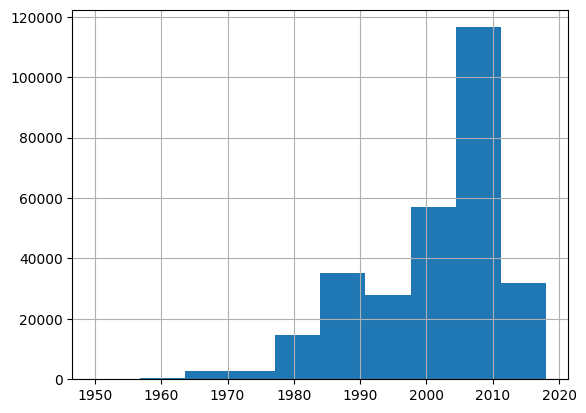

In [21]:
print(df['PROD_YEAR'].min())
df['PROD_YEAR'].hist()

In [22]:
insured_value_map = df.groupby(['TYPE_VEHICLE', 'MAKE'])['INSURED_VALUE'].agg('mean').to_dict()
# with open('insured_value_map.json', 'w') as f:
#     json.dump({' '.join(k): v for k, v in insured_value_map.items()}, f)

In [23]:
df.isna().sum()

SEX              0
INSR_TYPE        0
INSURED_VALUE    0
PREMIUM          0
OBJECT_ID        0
PROD_YEAR        0
SEATS_NUM        0
TYPE_VEHICLE     0
CCM_TON          0
MAKE             0
USAGE            0
DURATION         0
OLD_MAKE         0
dtype: int64

In [31]:
medians = df.median(numeric_only=True).to_dict()
medians['OBJECT_ID'] = -1
del medians['DURATION']
medians

{'SEX': 0.0,
 'INSR_TYPE': 1202.0,
 'INSURED_VALUE': 188223.77000000002,
 'PREMIUM': 3236.7,
 'OBJECT_ID': -1,
 'PROD_YEAR': 2005.0,
 'SEATS_NUM': 4.0,
 'CCM_TON': 2892.0}

In [25]:
df.columns

Index(['SEX', 'INSR_TYPE', 'INSURED_VALUE', 'PREMIUM', 'OBJECT_ID',
       'PROD_YEAR', 'SEATS_NUM', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE',
       'DURATION', 'OLD_MAKE'],
      dtype='str')

In [32]:
modes = df[['TYPE_VEHICLE', 'MAKE', 'USAGE']].mode()

In [34]:
modes.iloc[0].T.to_dict()

{'TYPE_VEHICLE': 'Truck', 'MAKE': 'TOYOTA', 'USAGE': 'Own Goods'}

In [ ]:
# with open('inference_nans_replacements.json', 'w') as f:
#     json.dump(medians | {'TYPE_VEHICLE': 'Truck', 'MAKE': 'TOYOTA', 'USAGE': 'Own Goods'}, f)

: 

In [ ]:
# df.to_csv('no_nans.csv', index=False)

: 

: 

# Тест написанного класса на схожесть результатов

In [ ]:
import pandas as pd
from pathlib import Path
from data_filtering import InsuranceDataProcessor

df1 = pd.read_csv('~/MLOps/vehicle-insurance-data/motor_data11-14lats.csv')
idp = InsuranceDataProcessor(Path('configs/filters'))

df1, nan_metrics = idp.handle_nans(df1, train=True)

print(df1.isna().sum().sum())
print(nan_metrics)

0
{'zero_duration_removed': 3783, 'duplicates_removed': 226, 'trade_plates_ccm_ton_nan': np.int64(2), 'trade_plates_seats_num_nan': np.int64(2), 'trade_plates_prod_year_nan': np.int64(2), 'premium_nan_count': np.int64(8), 'unknown_makes': np.int64(1304), 'CCM_TON_imputed': np.int64(34077), 'SEATS_NUM_imputed': np.int64(137), 'PROD_YEAR_imputed': np.int64(104), 'INSURED_VALUE_imputed': np.int64(0), 'remaining_nans': {'SEX': 0, 'INSR_TYPE': 0, 'INSURED_VALUE': 0, 'PREMIUM': 0, 'OBJECT_ID': 0, 'PROD_YEAR': 0, 'SEATS_NUM': 0, 'TYPE_VEHICLE': 0, 'CCM_TON': 0, 'MAKE': 0, 'USAGE': 0, 'START_MNTH': 0, 'DURATION': 0}}


: 

In [ ]:
df.columns, df1.columns

(Index(['SEX', 'INSR_TYPE', 'INSURED_VALUE', 'PREMIUM', 'OBJECT_ID',
        'PROD_YEAR', 'SEATS_NUM', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE',
        'DURATION', 'OLD_MAKE'],
       dtype='str'),
 Index(['SEX', 'INSR_TYPE', 'INSURED_VALUE', 'PREMIUM', 'OBJECT_ID',
        'PROD_YEAR', 'SEATS_NUM', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE',
        'DURATION', 'OBJECT_AGE'],
       dtype='str'))

: 

In [ ]:
assert (df.drop(columns=['OLD_MAKE']) == df1.drop(columns=['OBJECT_AGE'])).all().all()

: 